# Lesson 1 — Data representation and computation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-practice.ipynb)

Intellectual Data Analysis — practical part, lesson 1 of 3.

## Learning objectives

By the end of this session you should be able to:

- describe an `ndarray` in terms of its `dtype`, `shape` and underlying
  buffer, and explain why that layout is fast where a Python list is not;
- predict whether an indexing expression returns a view or a copy, and say
  what breaks when you guess wrong;
- apply the broadcasting rule to two shapes and say whether they align;
- reduce an array along a chosen axis and justify the choice;
- draw a sample from a named distribution with a seeded generator, recover
  the distribution's parameters from the sample, and state how far the
  recovered value should be from the true one;
- read a covariance matrix geometrically, as the shape and tilt of a cloud
  of points;
- build a figure from `Figure` and `Axes` objects and label it so that it
  can be read without its caption.

## Prerequisites

A bachelor's degree in a technical field. You can write a loop, a function
and a conditional in some language. No NumPy experience is assumed.

## Practicalities

- Written for **90-120 minutes** (2 to 3 academic hours) of class time.
- Measured end-to-end execution time: **about 2 seconds** on a clean kernel
  (reference machine, CPython 3.9, no GPU). The budget for this course is
  three minutes; this lesson is nowhere near it. The two `%timeit` cells in
  §3.3 report wall-clock timings, so those two numbers differ between runs
  by design. Every other number in the notebook is seeded and reproduces
  exactly.
- Homework: `1-homework.ipynb`, 3-4 hours.

## How this lesson fits

Lesson 1 is about *representation*: how a number, a column and a cloud of
points are stored, and what operations on them cost. Nothing here is a
model. Lesson 2 takes these arrays and gives them names, indexes and
missing values. Lesson 3 fits models to the two datasets built in §6.

## 1. Configuration

One cell, run once, at the top. It holds the imports, the random seed and
the display settings — and nothing else. In particular it does **not** hold
the location of any data. Every dataset in this course is loaded by writing
its full address at the point of use, so that a cell copied out of this
notebook still works.

The version numbers are printed so that if this notebook ever behaves
differently on your machine than in class, the first diagnostic question —
"are we running the same libraries" — is already answered on screen.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

# One seed for the whole notebook. Every random draw below traces back to it,
# so the numbers you see are the numbers your instructor sees.
SEED = 20250919
rng = np.random.default_rng(SEED)

# Display settings, set once. Figures are projected in a classroom, so the
# defaults are too small and too thin to read from the back.
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
import matplotlib
print("matplotlib ", matplotlib.__version__)

python      3.12.6
numpy       2.5.3
matplotlib  3.11.2


There is no `%matplotlib inline` in that cell. In a modern notebook,
inline figures are the default and have been for years; the line appears in
older tutorials as a habit rather than a requirement. If you meet it in
someone else's notebook it is harmless, not necessary.

## 2. Python for data work

This section is a calibration pass, not an introduction to programming. It
exists to fix the vocabulary and to make one point that matters for
everything after it: **the built-in containers are the wrong tool for
numerical work**, and §3 explains why.

### 2.1 Names, numbers and types

Assignment binds a name to an object. The object carries the type; the name
does not.

In [2]:
count = 7
ratio = 7 / 2          # true division always produces a float
floor_div = 7 // 2     # floor division keeps the integer type
power = 2 ** 10

print(count, type(count))
print(ratio, type(ratio))
print(floor_div, power)

7 <class 'int'>
3.5 <class 'float'>
3 1024


Note that `7 / 2` is `3.5` and not `3`. Python 3 made division produce a
float regardless of operand types; the integer-preserving operation has its
own operator. This is the first of several places in this course where a
silent type change is the cause of a later surprise.

### 2.2 Lists

A list is ordered, resizable, and heterogeneous: it can hold objects of
different types because it stores *references* to them, not the objects
themselves.

In [3]:
mixed = [1, 2.5, "three", [4, 5]]

print(mixed)
print([type(item).__name__ for item in mixed])
print("length:", len(mixed))

[1, 2.5, 'three', [4, 5]]
['int', 'float', 'str', 'list']
length: 4


That flexibility has a price, which §3.3 measures. A list of a million
numbers is a million pointers to a million separately allocated integer
objects scattered across memory.

### 2.3 Indexing and slicing

Indexing is zero-based. Negative indices count from the end. A slice
`a[start:stop]` includes `start` and excludes `stop`, so the length of the
result is `stop - start`.

In [4]:
values = [10, 20, 30, 40, 50]

print("first        ", values[0])
print("last         ", values[-1])
print("from index 1 ", values[1:])
print("all but last 2", values[:-2])
print("middle       ", values[1:4], "length", len(values[1:4]))

first         10
last          50
from index 1  [20, 30, 40, 50]
all but last 2 [10, 20, 30]
middle        [20, 30, 40] length 3


The half-open convention — `stop` excluded — is what makes `values[:k]` and
`values[k:]` partition the list with no overlap and no gap. Every slicing
API you meet in NumPy and pandas inherits it.

### 2.4 Mutation, append, and nested lists

Lists are mutable: you can assign into a slot and the object changes in
place.

In [5]:
values = [10, 20, 30, 40, 50]
values[2] = 999
values.append(60)
print(values)

matrix = [[1, 2, 3],
          [4, 5, 6]]

print("rows          ", len(matrix))
print("columns in row 0", len(matrix[0]))
print("element [0][0]  ", matrix[0][0])
print("element [1][2]  ", matrix[1][2])

[10, 20, 999, 40, 50, 60]
rows           2
columns in row 0 3
element [0][0]   1
element [1][2]   6


A list of lists is the obvious way to write a matrix and the wrong way to
compute with one. Nothing guarantees the rows have equal length, there is no
notion of a column, and `matrix * 2` repeats the outer list rather than
doubling the numbers. Confirm that last point before trusting it:

In [6]:
print([[1, 2], [3, 4]] * 2)   # list repetition, not elementwise arithmetic

[[1, 2], [3, 4], [1, 2], [3, 4]]


This is the concrete reason NumPy exists, and §3 starts there.

### 2.5 Dictionaries

A dictionary maps keys to values with average constant-time lookup. You will
meet it in this course as the return type of several scikit-learn objects
and as the natural way to name a set of parameters.

In [7]:
config = {"model": "linear", "degree": 2, "fit_intercept": True}

print(config["degree"])
print("keys  ", list(config.keys()))
print("items ", list(config.items()))
print("degree" in config)

2
keys   ['model', 'degree', 'fit_intercept']
items  [('model', 'linear'), ('degree', 2), ('fit_intercept', True)]
True


### 2.6 Comprehensions

A comprehension builds a list from an iterable in one expression. Read it
left to right as "collect *this*, for each *that*".

In [8]:
squares = [i ** 2 for i in range(5)]
evens = [i for i in range(10) if i % 2 == 0]

print(squares)
print(evens)
print([a + b for a, b in zip([1, 2, 3], [10, 20, 30])])

[0, 1, 4, 9, 16]
[0, 2, 4, 6, 8]
[11, 22, 33]


Comprehensions are idiomatic Python and they are still Python-level loops.
When the operand is an array, the vectorised form in §3.3 is both shorter
and one to two orders of magnitude faster.

### 2.7 Functions and tuple returns

A function returning several values returns a tuple, which the caller
usually unpacks. This pattern is everywhere in scikit-learn.

In [9]:
def summarize(sample):
    """Return the mean and the standard deviation of a sequence."""
    mean = sum(sample) / len(sample)
    variance = sum((x - mean) ** 2 for x in sample) / len(sample)
    return mean, variance ** 0.5

mean, sd = summarize([2, 4, 4, 4, 5, 5, 7, 9])
print(f"mean {mean:.3f}  sd {sd:.3f}")
print(summarize([1, 2, 3]))   # without unpacking it is visibly a tuple

mean 5.000  sd 2.000
(2.0, 0.816496580927726)


## 3. The ndarray

An `ndarray` is a fixed-size, homogeneously typed block of memory plus a
description of how to interpret it as a grid. Almost everything in this
course is an `ndarray`, including the objects pandas and scikit-learn hand
back to you.

### 3.1 From list to array

`np.array` copies the contents of a sequence into a new typed buffer.

In [10]:
from_list = np.array([1, 2, 3, 4, 5])
from_nested = np.array([[1, 2, 3],
                        [4, 5, 6]])

print(from_list, type(from_list).__name__)
print(from_nested)
print("a list is still a list:", type([1, 2, 3]).__name__)

[1 2 3 4 5] ndarray
[[1 2 3]
 [4 5 6]]
a list is still a list: list


The nested list became a genuine two-dimensional object rather than a
sequence of sequences. It now has a column, and the rows are guaranteed to
be the same length because a rectangular buffer cannot represent anything
else.

### 3.2 Anatomy of an array

Five attributes describe an array completely. Learn to read them together;
most shape bugs announce themselves here.

In [11]:
grid = np.array([[1, 2, 3],
                 [4, 5, 6]])

print("dtype    ", grid.dtype)     # the type of every element, uniformly
print("shape    ", grid.shape)     # length along each dimension
print("ndim     ", grid.ndim)      # number of dimensions == len(shape)
print("size     ", grid.size)      # total number of elements
print("itemsize ", grid.itemsize, "bytes per element")
print("nbytes   ", grid.nbytes, "bytes in total")

dtype     int64
shape     (2, 3)
ndim      2
size      6
itemsize  8 bytes per element
nbytes    48 bytes in total


`nbytes` is exactly `size * itemsize`: there is no per-element overhead,
because there are no per-element objects. That single fact is the whole
performance story, and §3.3 measures it.

The `dtype` is fixed at construction and it is contagious. Mixing types
forces a common one, and the choice can be lossy:

In [12]:
print(np.array([1, 2, 3]).dtype)            # integers
print(np.array([1, 2, 3.5]).dtype)          # one float promotes all of them
print(np.array([1, 2, "3"]).dtype)          # one string demotes all to text

# An explicit dtype truncates rather than rounds, silently.
print(np.array([1.9, 2.9, -1.9], dtype=int))

int64
float64
<U21
[ 1  2 -1]


`np.array([1, 2, "3"])` produced a string array, not an array of numbers.
Arithmetic on it will fail or concatenate. When a column of numbers arrives
from a CSV with one stray non-numeric entry, this is what you get, and
Practice 2 §3 shows the pandas version of the same accident.

### 3.3 Why the typed buffer is fast

Claim: operating on an array is one to two orders of magnitude faster than
the equivalent Python loop. Measure it rather than believe it.

In [13]:
n = 1_000_000
py_list = list(range(n))
np_array = np.arange(n)

print("list comprehension over", n, "elements:")
%timeit -r 3 -n 1 [x * 2 for x in py_list]

list comprehension over 1000000 elements:
19.8 ms ± 2.51 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [14]:
print("vectorised array multiply over", n, "elements:")
%timeit -r 3 -n 10 np_array * 2

vectorised array multiply over 1000000 elements:
1.64 ms ± 258 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


Two effects combine. The array loop runs in compiled C with no interpreter
dispatch per element, and the array data is contiguous, so the processor's
prefetcher and cache work in its favour while the list version chases
pointers around the heap.

The practical rule for the rest of the course: **if you are writing a
`for` loop over the elements of an array, look for the array operation
first.** The loop is not wrong, it is slow and usually longer to read.

Timings vary between runs and between machines, so these two numbers will
not reproduce exactly. The ratio will.

### 3.4 Creating arrays

You rarely type the numbers. These are the constructors used throughout the
course.

In [15]:
print("arange(5)           ", np.arange(5))
print("arange(2, 10, 3)    ", np.arange(2, 10, 3))     # start, stop, step
print("linspace(0, 1, 5)   ", np.linspace(0, 1, 5))    # start, stop, count
print("zeros(3)            ", np.zeros(3))
print("ones((2, 3))        ", np.ones((2, 3)).tolist())
print("full(3, 7.5)        ", np.full(3, 7.5))
print("eye(3)              ", np.eye(3).tolist())

arange(5)            [0 1 2 3 4]
arange(2, 10, 3)     [2 5 8]
linspace(0, 1, 5)    [0.   0.25 0.5  0.75 1.  ]
zeros(3)             [0. 0. 0.]
ones((2, 3))         [[1.0, 1.0, 1.0], [1.0, 1.0, 1.0]]
full(3, 7.5)         [7.5 7.5 7.5]
eye(3)               [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]


`arange` takes a *step* and excludes the stop value; `linspace` takes a
*count* and includes it. Use `linspace` whenever you want a grid of a known
number of points, which for plotting is almost always.

In [16]:
# The difference, stated as a fact you can check:
print("arange stop excluded :", np.arange(0, 1, 0.25))
print("linspace stop included:", np.linspace(0, 1, 5))

arange stop excluded : [0.   0.25 0.5  0.75]
linspace stop included: [0.   0.25 0.5  0.75 1.  ]


### 3.5 Reshaping, and `reshape(-1, 1)`

`reshape` reinterprets the same buffer under a new shape. The number of
elements cannot change.

In [17]:
flat = np.arange(10)
print(flat.reshape(2, 5))
print(flat.reshape(5, 2).shape)

# -1 means "infer this dimension from the total size".
print("reshape(-1, 2) ->", flat.reshape(-1, 2).shape)

[[0 1 2 3 4]
 [5 6 7 8 9]]
(5, 2)
reshape(-1, 2) -> (5, 2)


One special case is worth memorising now, because it recurs in every
scikit-learn call in Lesson 3.

A scikit-learn estimator expects its feature argument `X` to be
two-dimensional, with **one row per sample and one column per feature**,
even when there is only one feature. A plain 1-D array of `n` measurements
has shape `(n,)`, which is ambiguous: it could mean `n` samples of one
feature or one sample of `n` features. `reshape(-1, 1)` resolves it in
favour of the first reading.

In [18]:
measurements = np.array([1.0, 2.0, 3.0, 4.0])

print("1-D shape ", measurements.shape)                  # ambiguous to sklearn
print("as column ", measurements.reshape(-1, 1).shape)   # 4 samples, 1 feature
print("as row    ", measurements.reshape(1, -1).shape)   # 1 sample, 4 features
print()
print(measurements.reshape(-1, 1))

1-D shape  (4,)
as column  (4, 1)
as row     (1, 4)

[[1.]
 [2.]
 [3.]
 [4.]]


Read `reshape(-1, 1)` as "make this a column". When Lesson 3 writes
`X = x.reshape(-1, 1)` it means exactly this and nothing more.

### 3.6 Views and copies

**A slice of an array is a view, not a copy.** It shares the parent's
memory. Writing through the view writes into the parent. This is the single
most common silent data corruption in student code, so here it is as a bug
before it is a rule.

In [19]:
original = np.arange(10)
window = original[3:6]     # a view onto elements 3, 4, 5

window[:] = 0              # intended to modify only `window`

print("window  ", window)
print("original", original)     # the parent changed too

window   [0 0 0]
original [0 1 2 0 0 0 6 7 8 9]


Nothing warned you. The array `original` was modified by an assignment that
never mentions it. If `original` were a column of measurements and `window`
a subset you were experimenting on, the experiment has just destroyed the
data.

`.copy()` makes the independence explicit:

In [20]:
original = np.arange(10)
window = original[3:6].copy()   # an independent buffer

window[:] = 0

print("window  ", window)
print("original", original)     # untouched

window   [0 0 0]
original [0 1 2 3 4 5 6 7 8 9]


You can always ask an array whether it owns its memory:

In [21]:
original = np.arange(10)
print("slice owns its data? ", original[3:6].base is None)
print("copy owns its data?  ", original[3:6].copy().base is None)

slice owns its data?  False
copy owns its data?   True


The rule in practice: **basic slicing gives a view; fancy indexing and
boolean masking give a copy** (§3.9). When you are about to mutate, and you
did not create the array in the same cell, call `.copy()`.

Views are not a design flaw. They are why NumPy can hand you a row of a
large matrix without duplicating it. The cost of that efficiency is that
you have to know when you are holding one.

### 3.7 Broadcasting

Elementwise operations between arrays of *different* shapes are allowed
when the shapes are compatible. NumPy does not duplicate data to make this
work; it iterates cleverly. The rule is precise and worth stating exactly.

**Align the shapes on their trailing dimensions. Reading right to left,
each pair of dimensions must be equal, or one of them must be 1.** A
missing leading dimension counts as 1.

Start with the simplest case, an array and a scalar:

In [22]:
values = np.array([1.0, 2.0, 3.0])

print(values + 10)     # the scalar is stretched across all three positions
print(values * 2)
print(values ** 2)

[11. 12. 13.]
[2. 4. 6.]
[1. 4. 9.]


Now two genuine arrays. A `(3, 1)` column and a `(1, 4)` row broadcast to a
`(3, 4)` grid — this is how you build a multiplication table without a
loop:

In [23]:
column = np.arange(1, 4).reshape(3, 1)    # shape (3, 1)
row = np.arange(1, 5).reshape(1, 4)       # shape (1, 4)

print("column shape", column.shape, " row shape", row.shape)
print(column * row)                        # shape (3, 4)

column shape (3, 1)  row shape (1, 4)
[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]]


Work the rule by hand for that example. Right to left: `1` against `4` — one
of them is 1, so they align and the result is 4. Then `3` against `1` — again
one is 1, so the result is 3. Final shape `(3, 4)`.

A case that does **not** align, deliberately, so you have read the error
message once before you meet it under time pressure:

In [24]:
# DELIBERATE ERROR. The shapes (3,) and (4,) do not broadcast:
# right to left, 3 against 4, neither is equal nor 1.
try:
    np.array([1, 2, 3]) + np.array([1, 2, 3, 4])
except ValueError as exc:
    print("ValueError:", exc)

ValueError: operands could not be broadcast together with shapes (3,) (4,) 


The message names both shapes and the axis that failed. When you see it,
print the `.shape` of both operands before doing anything else; the fix is
almost always a missing `reshape(-1, 1)` or an accidental transpose.

The most common real use of broadcasting is centring: subtracting a
per-column mean from every row.

In [25]:
data = np.array([[1.0, 10.0],
                 [2.0, 20.0],
                 [3.0, 30.0]])

column_means = data.mean(axis=0)          # shape (2,)
centred = data - column_means             # (3, 2) - (2,) -> (3, 2)

print("column means", column_means)
print(centred)
print("means after centring", centred.mean(axis=0))

column means [ 2. 20.]
[[ -1. -10.]
 [  0.   0.]
 [  1.  10.]]
means after centring [0. 0.]


That is `StandardScaler` doing half its job, written out. Practice 2 §14.1
uses the scikit-learn object; it does exactly this, and then divides by the
per-column standard deviation.

### 3.8 Axes and reductions

A reduction collapses one or more dimensions. `axis` names the dimension
that **disappears**, which is the opposite of the way most people first
read it.

In [26]:
grid = np.array([[1, 2, 3],
                 [4, 5, 6]])
print(grid, "shape", grid.shape)
print()
print("sum()        ", grid.sum(), "  -> scalar, all axes collapsed")
print("sum(axis=0)  ", grid.sum(axis=0), "-> shape", grid.sum(axis=0).shape, ", rows collapsed, one value per column")
print("sum(axis=1)  ", grid.sum(axis=1), "   -> shape", grid.sum(axis=1).shape, ", columns collapsed, one value per row")

[[1 2 3]
 [4 5 6]] shape (2, 3)

sum()         21   -> scalar, all axes collapsed
sum(axis=0)   [5 7 9] -> shape (3,) , rows collapsed, one value per column
sum(axis=1)   [ 6 15]    -> shape (2,) , columns collapsed, one value per row


`axis=0` collapses the row dimension and therefore aggregates **down the
columns**. If you can only remember one form, remember that `axis=0` gives
you one number per column, which is what you want for per-feature
statistics.

`keepdims=True` retains the collapsed dimension with length 1, so the
result still broadcasts against the original:

In [27]:
row_sums = grid.sum(axis=1)
row_sums_kept = grid.sum(axis=1, keepdims=True)

print("without keepdims", row_sums.shape, row_sums)
print("with keepdims   ", row_sums_kept.shape)
print(row_sums_kept)
print()
print("row-normalised (each row sums to 1):")
print(grid / row_sums_kept)

without keepdims (2,) [ 6 15]
with keepdims    (2, 1)
[[ 6]
 [15]]

row-normalised (each row sums to 1):
[[0.16666667 0.33333333 0.5       ]
 [0.26666667 0.33333333 0.4       ]]


Without `keepdims` that last division would have failed: `(2, 3)` against
`(2,)` aligns 3 with 2 and stops. This is the second most common
broadcasting bug after the missing column reshape.

The other reductions behave the same way. Note the distinction the drafts
made explicitly, and keep it: `max` returns the **value**, `argmax` returns
the **index** of that value.

In [28]:
sample = np.array([3.0, 9.0, 4.0, 1.0])

print("max    ", sample.max(), "  the largest value")
print("argmax ", sample.argmax(), "    the position of the largest value")
print("min    ", sample.min(), "  argmin", sample.argmin())
print("mean   ", sample.mean(), " std", sample.std().round(4))
print("sum    ", sample.sum(), " cumsum", sample.cumsum())
print()
print("recovering the value from the index:", sample[sample.argmax()])

max     9.0   the largest value
argmax  1     the position of the largest value
min     1.0   argmin 3
mean    4.25  std 2.9475
sum     17.0  cumsum [ 3. 12. 16. 17.]

recovering the value from the index: 9.0


Elementwise arithmetic between two arrays of the **same** shape pairs them
position by position, and the universal functions apply to every element.

In [29]:
left = np.array([1.0, 2.0, 3.0])
right = np.array([10.0, 20.0, 30.0])

print("left + right", left + right)
print("left * right", left * right)     # elementwise, NOT a dot product
print("np.exp      ", np.exp(left).round(4))
print("np.log      ", np.log(right).round(4))
print("np.sqrt     ", np.sqrt(np.array([1.0, 4.0, 9.0])))
print()
print("the dot product is a separate operation:", left @ right)

left + right [11. 22. 33.]
left * right [10. 40. 90.]
np.exp       [ 2.7183  7.3891 20.0855]
np.log       [2.3026 2.9957 3.4012]
np.sqrt      [1. 2. 3.]

the dot product is a separate operation: 140.0


`*` is elementwise and `@` is matrix multiplication. In a language where
`*` on matrices means the matrix product this is a frequent source of
silently wrong results rather than errors, because for square operands both
are legal.

### 3.9 Boolean masking and fancy indexing

Comparing an array with a scalar produces a **boolean array** of the same
shape, not a single `True` or `False`.

In [30]:
sample = np.array([3.0, 9.0, 4.0, 1.0, 12.0, 7.0])
mask = sample > 5

print("sample", sample)
print("mask  ", mask, mask.dtype)
print("count of True:", mask.sum())          # booleans sum as 0 and 1
print("any / all:", mask.any(), mask.all())

sample [ 3.  9.  4.  1. 12.  7.]
mask   [False  True False False  True  True] bool
count of True: 3
any / all: True False


`mask.sum()` counts matches because `True` is 1 under arithmetic. This
idiom — build a condition, sum it — replaces most counting loops.

Indexing with the mask selects the positions where it is `True`, returning
a **copy**:

In [31]:
print("selected values ", sample[mask])
print("inverted (~)    ", sample[~mask])
print("combined        ", sample[(sample > 3) & (sample < 10)])
print()
print("this is a copy, not a view:", sample[mask].base is None)

selected values  [ 9. 12.  7.]
inverted (~)     [3. 4. 1.]
combined         [9. 4. 7.]

this is a copy, not a view: True


Note the parentheses and the `&`. NumPy uses `&`, `|` and `~` for
elementwise boolean logic; the Python keywords `and`, `or` and `not`
operate on whole objects and raise on an array. The operators bind more
tightly than the comparisons, so the parentheses are required.

**Fancy indexing** selects by an array of positions rather than a
condition, and also copies:

In [32]:
print("positions 0, 2, 5   ", sample[[0, 2, 5]])
print("reversed by fancy idx", sample[[5, 4, 3, 2, 1, 0]])
print("sorted order         ", np.sort(sample))
print("argsort (the order)  ", np.argsort(sample))
print("sample[argsort]      ", sample[np.argsort(sample)])

positions 0, 2, 5    [3. 4. 7.]
reversed by fancy idx [ 7. 12.  1.  4.  9.  3.]
sorted order          [ 1.  3.  4.  7.  9. 12.]
argsort (the order)   [3 0 2 5 1 4]
sample[argsort]       [ 1.  3.  4.  7.  9. 12.]


`argsort` returns the *permutation* that would sort the array. Applying it
as a fancy index performs the sort, and applying it to a second array sorts
that one into the same order — which is how you keep features and labels
aligned.

### 3.10 Missing values and `np.nan`

`np.nan` is a float that represents "not a number". It has one property
that catches everyone: **it is not equal to itself.**

In [33]:
print("np.nan == np.nan :", np.nan == np.nan)      # False, always
print("np.isnan works   :", np.isnan(np.nan))

np.nan == np.nan : False
np.isnan works   : True


So you cannot find missing values with `==`. You need `np.isnan`, and in
Lesson 2 the pandas equivalent `isna`.

`NaN` also poisons any reduction that touches it:

In [34]:
with_gap = np.array([1.0, 2.0, np.nan, 4.0])

print("mean     ", with_gap.mean(), "  one missing value destroys the answer")
print("nanmean  ", np.nanmean(with_gap), " the nan-aware version skips it")
print("sum/nansum", with_gap.sum(), np.nansum(with_gap))
print("count of missing:", np.isnan(with_gap).sum())

mean      nan   one missing value destroys the answer
nanmean   2.3333333333333335  the nan-aware version skips it
sum/nansum nan 7.0
count of missing: 1


Both behaviours are defensible. The propagating default is honest: the true
mean of a sample containing an unknown value *is* unknown. `nanmean` makes
the assumption that the missing values can be ignored, which is a decision
about the data and not a formatting choice. Practice 2 §5 is entirely about
when that assumption holds.

Note also that `np.nan` is a float, so **an integer array cannot hold a
missing value**. Reading a column of integers with one gap gives you floats:

In [35]:
print(np.array([1, 2, 3]).dtype)
print(np.array([1, 2, np.nan]).dtype)      # promoted to float to make room

int64
float64


### 3.11 Floating point

Binary floating point cannot represent most decimal fractions exactly. This
is not a NumPy property; it is how the hardware works.

In [36]:
print("0.1 + 0.2       =", 0.1 + 0.2)
print("equals 0.3?      ", 0.1 + 0.2 == 0.3)
print("the difference   ", (0.1 + 0.2) - 0.3)

0.1 + 0.2       = 0.30000000000000004
equals 0.3?       False
the difference    5.551115123125783e-17


Never compare floats with `==`. Compare with a tolerance:

In [37]:
print("np.isclose  ", np.isclose(0.1 + 0.2, 0.3))
print("allclose on arrays:", np.allclose(np.array([0.1 + 0.2, 1/3]),
                                         np.array([0.3, 0.33333333333])))

np.isclose   True
allclose on arrays: True


This matters directly in the homework, where assertions on computed floats
use `np.isclose` rather than `==`, and in Lesson 3, where two mathematically
equivalent routes to the same coefficient will differ in the last few
digits.

## 4. Randomness, distributions and reproducibility

Synthetic data is how you test an analysis method when you know the right
answer. Every synthetic dataset in this course is built here, from a
generator you can read, rather than conjured by a library function — for
the reason given in `practice/README.md` §6.

### 4.1 The generator object, and why the seed is not optional

The modern NumPy interface is an explicit **generator object**. You create
one with a seed and draw from it.

In [38]:
first = np.random.default_rng(42)
second = np.random.default_rng(42)

print("first :", first.normal(size=4).round(4))
print("second:", second.normal(size=4).round(4))
print("identical:", np.array_equal(np.random.default_rng(42).normal(size=4),
                                   np.random.default_rng(42).normal(size=4)))

first : [ 0.3047 -1.04    0.7505  0.9406]
second: [ 0.3047 -1.04    0.7505  0.9406]
identical: True


Same seed, same stream. This is what makes a result checkable: a colleague
who runs your notebook gets your numbers, a instructor narrating a slide is
describing what is on the screen, and a bug that appears once can be made
to appear again.

A generator is **stateful**. Drawing from it advances it, so two successive
calls differ:

In [39]:
gen = np.random.default_rng(42)
print("draw 1:", gen.normal(size=3).round(4))
print("draw 2:", gen.normal(size=3).round(4))   # different: the state moved on

draw 1: [ 0.3047 -1.04    0.7505]
draw 2: [ 0.9406 -1.951  -1.3022]


This is why the notebook creates `rng` once, in §1, and every later cell
draws from it. It also means that **running cells out of order changes the
numbers**, which is a preview of the reproducibility argument in
`practice/README.md` §5. Restart and run all is the only state you can
reason about.

### 4.2 The legacy interface

You will meet a second, older API in almost every tutorial online, and in
the drafts this course replaces. It uses a single hidden global generator:

```python
np.random.seed(0)          # seeds a process-wide generator
np.random.normal(size=3)   # draws from that hidden global
```

It works, and it is discouraged for new code. The hidden state is global,
so any library you call can advance it or reseed it without telling you,
and a function that draws random numbers has no way to be handed its own
independent stream. The modern API makes the dependency explicit: a
function that needs randomness takes an `rng` argument.

Recognise it, do not write it. This course uses `default_rng` everywhere.

In [40]:
# Shown once so that you recognise it in other people's code.
np.random.seed(0)
legacy_draw = np.random.normal(size=3)

modern_draw = np.random.default_rng(0).normal(size=3)

print("legacy np.random.seed(0):", legacy_draw.round(4))
print("modern default_rng(0)   :", modern_draw.round(4))
print()
print("Different numbers. The two APIs do not share a seed or an algorithm,")
print("so you cannot reproduce a legacy result by porting the seed across.")

legacy np.random.seed(0): [1.7641 0.4002 0.9787]
modern default_rng(0)   : [ 0.1257 -0.1321  0.6404]

Different numbers. The two APIs do not share a seed or an algorithm,
so you cannot reproduce a legacy result by porting the seed across.


That last point is practical. If you are reproducing a published notebook
that used `np.random.seed`, you must keep the legacy calls to get the
published numbers; switching to `default_rng` with the same integer gives a
different, equally valid sample.

### 4.3 The uniform distribution

Every value in the interval equally likely. `low` inclusive, `high`
exclusive.

In [41]:
uniform_sample = rng.uniform(low=0.0, high=5.0, size=10)

print(uniform_sample.round(3))
print("min", uniform_sample.min().round(3), " max", uniform_sample.max().round(3))

[3.394 4.265 4.391 0.83  1.927 3.895 1.777 0.994 3.888 3.137]
min 0.83  max 4.391


### 4.4 The normal distribution

Two parameters: the mean `loc` and the standard deviation `scale`.

In [42]:
normal_sample = rng.normal(loc=0.0, scale=1.0, size=10)

print(normal_sample.round(3))

# `standard_normal` is the loc=0, scale=1 case, written more directly.
print(rng.standard_normal(5).round(3))

[-0.919  0.768 -1.111  1.06   0.022  0.359  0.224  1.038 -0.081  0.75 ]
[ 0.189  1.207  1.131 -0.782  1.028]


### 4.5 Uniform against normal, as histograms

The difference between the two is easiest to see as a shape. Draw a large
sample from each and overlay them.

Two arguments in the call below are doing real work. `bins=50` fixes the
resolution of the histogram, and `density=True` normalises the bars so that
their total area is 1 — which is what makes two samples of different sizes,
or two distributions with different spreads, comparable on one axis.

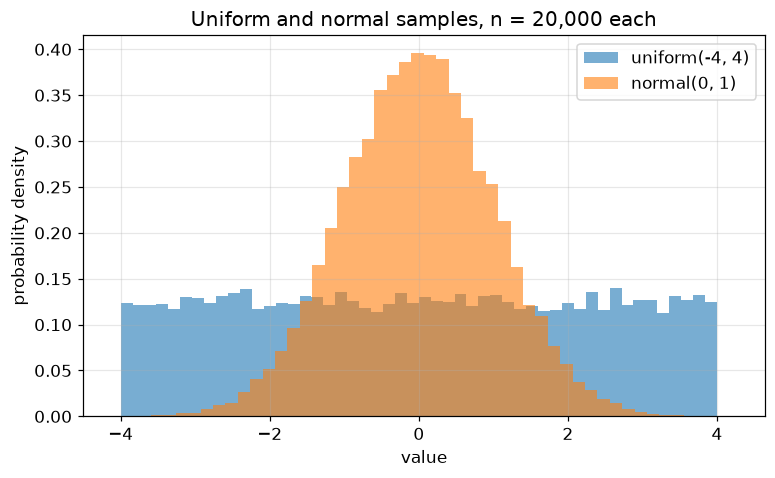

In [43]:
n_samples = 20_000
uniform_large = rng.uniform(-4, 4, n_samples)
normal_large = rng.normal(0, 1, n_samples)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(uniform_large, bins=50, density=True, alpha=0.6, label="uniform(-4, 4)")
ax.hist(normal_large, bins=50, density=True, alpha=0.6, label="normal(0, 1)")
ax.set_xlabel("value")
ax.set_ylabel("probability density")
ax.set_title(f"Uniform and normal samples, n = {n_samples:,} each")
ax.legend()
plt.show()

The uniform sample is flat across its support and stops abruptly at the
boundaries. The normal sample is concentrated near its mean and has no
boundary at all — it merely becomes very unlikely far out.

The height of the uniform block is about 0.125, which is `1 / 8`, because
the density of a uniform distribution over an interval of width 8 must
integrate to 1. That is a check you can do in your head whenever
`density=True` is set.

### 4.6 Recovering the parameters from a sample

If a sample came from `normal(mu, sigma)`, the sample mean and sample
standard deviation estimate `mu` and `sigma`. They do not equal them.

In [44]:
true_mu, true_sigma = 3.0, 2.0

for n in (50, 500, 5_000, 50_000):
    sample = rng.normal(true_mu, true_sigma, n)
    print(f"n = {n:6,}   mean = {sample.mean():7.4f}   std = {sample.std(ddof=1):7.4f}")

print(f"\ntrue values      mu = {true_mu:.4f}       sigma = {true_sigma:.4f}")

n =     50   mean =  3.3878   std =  1.9258
n =    500   mean =  3.0116   std =  1.9399
n =  5,000   mean =  3.0124   std =  2.0013
n = 50,000   mean =  3.0133   std =  1.9902

true values      mu = 3.0000       sigma = 2.0000


The estimates approach the truth as the sample grows, and the error falls
roughly with the square root of `n`: a hundredfold increase in data buys a
tenfold improvement in precision. That relationship is the reason "collect
more data" has diminishing returns, and it is worth having a feel for
before Lesson 3 asks you to read a difference between two model scores.

Note `ddof=1`. NumPy's default `std()` divides by `n`, which underestimates
the population standard deviation; `ddof=1` divides by `n - 1`, which is the
unbiased estimator. At `n = 50` the difference is about one per cent, at
`n = 50 000` it is invisible. pandas defaults to `ddof=1` and NumPy defaults
to `ddof=0`, so the same column can give you two different numbers
depending on which library you asked.

In [45]:
small = rng.normal(0, 1, 20)
print("np.std default (ddof=0):", small.std().round(5))
print("unbiased      (ddof=1):", small.std(ddof=1).round(5))

np.std default (ddof=0): 0.92606
unbiased      (ddof=1): 0.95011


### 4.7 The three-sigma rule, as boolean masking

For a normal distribution, about 68 % of the mass lies within one standard
deviation of the mean, 95 % within two, and 99.7 % within three. So a point
more than three standard deviations out is unusual — roughly 3 in 1000 — and
is often treated as an outlier.

The draft this replaces performed exactly this filter. Name the technique:
it is boolean masking from §3.9 with a statistically motivated threshold.

In [46]:
mu, sigma = 0.0, 1.0
observations = rng.normal(mu, sigma, 10_000)

deviation = np.abs(observations - mu)
outlier_mask = deviation > 3 * sigma          # a boolean array, §3.9
outliers = observations[outlier_mask]

print("sample size      ", observations.size)
print("flagged as outlier", outlier_mask.sum())
print("that is           ", f"{100 * outlier_mask.mean():.2f} %")
print("expected for a normal sample: about 0.27 %")
print("most extreme values:", np.sort(outliers)[[0, -1]].round(3))

sample size       10000
flagged as outlier 20
that is            0.20 %
expected for a normal sample: about 0.27 %
most extreme values: [-3.714  3.976]


Read the result carefully, because it contains the central caution about
outlier detection. These points are **not** errors. They were drawn from
exactly the same normal distribution as every other point, and a sample of
10 000 is *expected* to contain about 27 of them. A rule that flags them has
found the tail of the distribution, not a fault in the data.

Whether a flagged point is an error or a signal is a question about the
measurement process, not about the number. Practice 2 §10.5 puts the same
question to a real variable, the Titanic fares, where the extreme values
are genuine first-class tickets and deleting them would delete the effect
under study.

### 4.8 Integers and sampling from a set

Two more draws that recur in the course: integers, and sampling from an
existing collection.

In [47]:
print("randint-style :", rng.integers(low=0, high=10, size=10))
print("choice        :", rng.choice(["a", "b", "c"], size=8))
print("without repl. :", rng.choice(np.arange(10), size=5, replace=False))

deck = np.arange(10)
rng.shuffle(deck)          # shuffles in place
print("shuffled      :", deck)

randint-style : [4 4 5 4 5 2 1 6 4 6]
choice        : ['b' 'b' 'a' 'c' 'a' 'a' 'c' 'a']
without repl. : [9 7 0 5 3]
shuffled      : [5 4 2 1 0 9 7 8 6 3]


`rng.integers` excludes `high` by default, matching `range` and `arange`.
The legacy `np.random.randint` behaves the same way; the legacy
`np.random.random_integers` did not, which is why it was removed.

### 4.9 Two dimensions: the covariance matrix read geometrically

A multivariate normal is specified by a mean **vector** and a covariance
**matrix**. For two dimensions the covariance matrix is

```
[[var(x),     cov(x, y)],
 [cov(x, y),  var(y)   ]]
```

The diagonal sets the spread along each axis; the off-diagonal sets how the
two coordinates move together. Read it as geometry.

Start with a diagonal matrix, which means the coordinates are uncorrelated.
The draft wrote `[[10*10, 0], [0, 3*3]]` and annotated it "68 % in range
-10..10". Make that rigorous: the entries are **variances**, so they are
standard deviations squared, and the 68 % interval is one standard
deviation wide.

In [48]:
mean_vector = np.array([0.0, 0.0])
sigma_x, sigma_y = 10.0, 3.0
cov_diagonal = np.array([[sigma_x ** 2, 0.0],
                         [0.0, sigma_y ** 2]])

cloud = rng.multivariate_normal(mean_vector, cov_diagonal, size=4_000)

print("covariance matrix used:\n", cov_diagonal)
print("\nsigma_x =", sigma_x, "-> about 68 % of x within", (-sigma_x, sigma_x))
print("sigma_y =", sigma_y, "-> about 68 % of y within", (-sigma_y, sigma_y))
print("\nmeasured fraction of x within one sigma:",
      round(float(np.mean(np.abs(cloud[:, 0]) < sigma_x)), 4))
print("measured fraction of y within one sigma:",
      round(float(np.mean(np.abs(cloud[:, 1]) < sigma_y)), 4))

covariance matrix used:
 [[100.   0.]
 [  0.   9.]]

sigma_x = 10.0 -> about 68 % of x within (-10.0, 10.0)
sigma_y = 3.0 -> about 68 % of y within (-3.0, 3.0)

measured fraction of x within one sigma: 0.679
measured fraction of y within one sigma: 0.6753


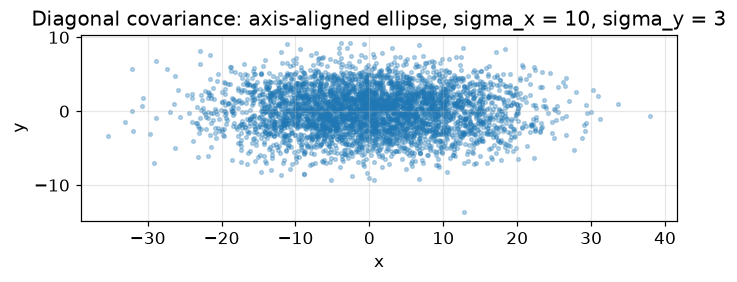

In [49]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(cloud[:, 0], cloud[:, 1], s=6, alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Diagonal covariance: axis-aligned ellipse, sigma_x = 10, sigma_y = 3")
ax.set_aspect("equal")
plt.show()

The cloud is an axis-aligned ellipse, wide in `x` and narrow in `y`, in the
ratio 10 to 3. `set_aspect("equal")` matters here: without it matplotlib
stretches the axes independently and the shape you are trying to
demonstrate is an artifact of the figure size rather than of the data.

Now make the off-diagonal non-zero. This is the case the drafts never
showed, and it is the one that carries the idea.

In [50]:
cov_correlated = np.array([[9.0, 6.0],
                           [6.0, 9.0]])      # var 9 and 9, covariance 6

tilted = rng.multivariate_normal(mean_vector, cov_correlated, size=4_000)

# Correlation is covariance normalised by the two standard deviations.
correlation = 6.0 / np.sqrt(9.0 * 9.0)
print("covariance matrix:\n", cov_correlated)
print("\nimplied correlation:", round(correlation, 3))
print("measured correlation:", round(float(np.corrcoef(tilted.T)[0, 1]), 3))

covariance matrix:
 [[9. 6.]
 [6. 9.]]

implied correlation: 0.667
measured correlation: 0.665


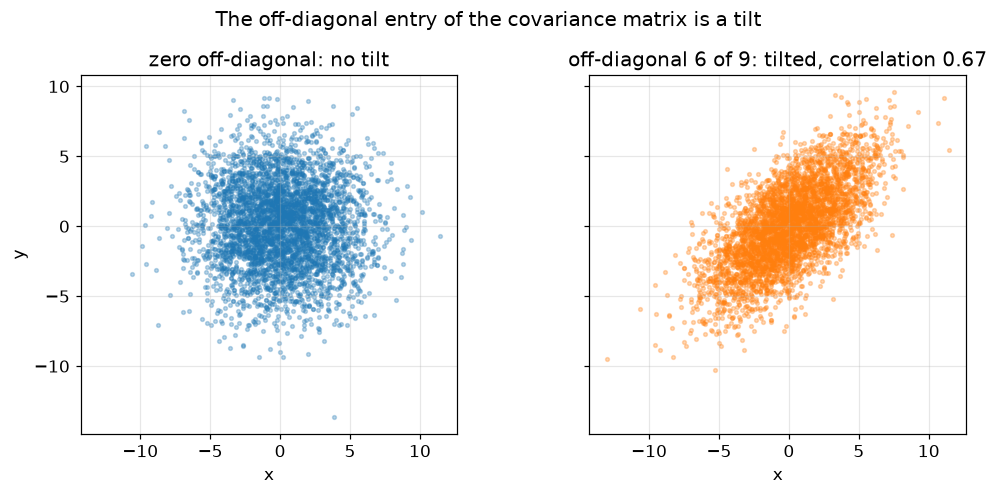

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

axes[0].scatter(cloud[:, 0] * 0.3, cloud[:, 1], s=6, alpha=0.3)
axes[0].set_title("zero off-diagonal: no tilt")

axes[1].scatter(tilted[:, 0], tilted[:, 1], s=6, alpha=0.3, color="tab:orange")
axes[1].set_title("off-diagonal 6 of 9: tilted, correlation 0.67")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_aspect("equal")
axes[0].set_ylabel("y")
fig.suptitle("The off-diagonal entry of the covariance matrix is a tilt")
fig.tight_layout()
plt.show()

A positive off-diagonal tilts the cloud up to the right: knowing `x` tells
you something about `y`. A negative one tilts it down. Zero leaves it
axis-aligned.

This picture is the whole of Practice 2 §11, where the correlation
coefficient measures that tilt for real columns, and it returns in Practice 3
§14, where a clustering method that assumes axis-aligned, equally sized
blobs is given tilted data and visibly fails.

## 5. Plotting with matplotlib

Every figure above was built the same way: `fig, ax = plt.subplots()`, then
methods on `ax`. That is the object-oriented interface. `fig` is the whole
canvas and `ax` is one set of axes drawn on it; you hold both as ordinary
Python objects and configure them by calling methods.

There is a second interface, `plt.plot(...)` / `plt.xlabel(...)`, which
draws on a "current" figure that matplotlib tracks for you. It is shorter
for one-off plots and it becomes ambiguous the moment there is more than
one set of axes in play. Practice 2 §9 puts the two side by side and shows
where the state machine breaks down. This lesson uses the explicit form
throughout, so that the habit is already in place.

### 5.1 A line plot

`ax.plot(x, y)` draws a line through the points in order. To plot a
function, evaluate it on a dense grid from `linspace`.

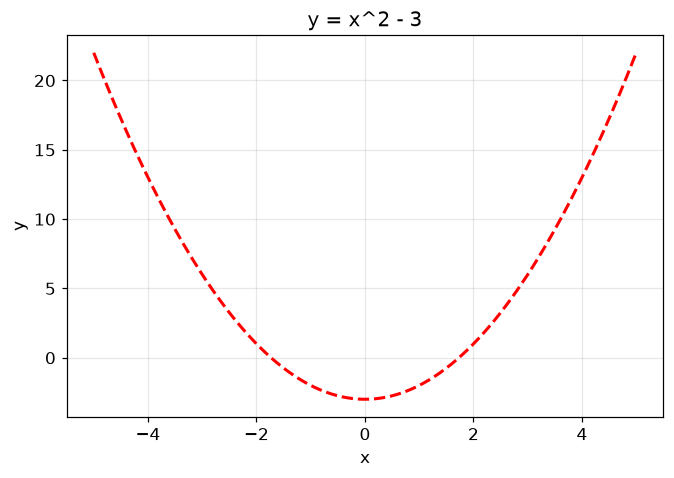

In [52]:
x = np.linspace(-5, 5, 200)
y = x ** 2 - 3

fig, ax = plt.subplots()
ax.plot(x, y, "r--")            # format string: red, dashed
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("y = x^2 - 3")
plt.show()

`"r--"` is a **format string**, a compact abbreviation for colour, marker
and line style. `r` is red, `--` is a dashed line. It is convenient and
limited; the keyword form `color="red", linestyle="--"` accepts any colour
and is what you should reach for when the abbreviation runs out.

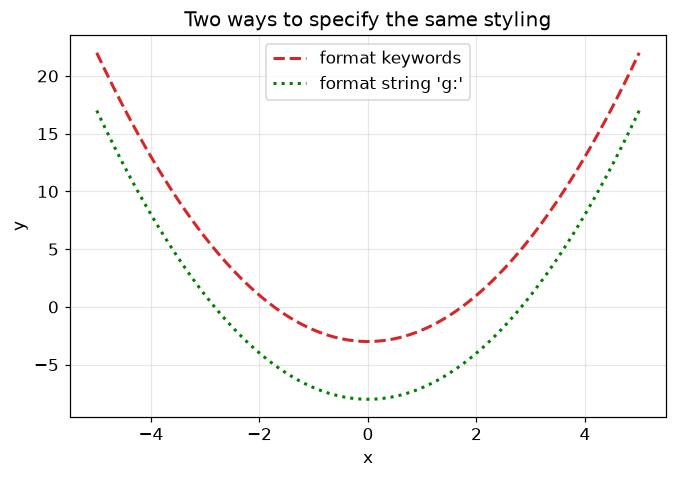

In [53]:
fig, ax = plt.subplots()
ax.plot(x, y, color="tab:red", linestyle="--", linewidth=2, label="format keywords")
ax.plot(x, y - 5, "g:", label="format string 'g:'")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Two ways to specify the same styling")
ax.legend()
plt.show()

### 5.2 Several curves on one axes, and the legend

Call `plot` more than once on the same `ax`. Each call takes a `label`, and
`ax.legend()` collects them. Without the labels the legend has nothing to
show.

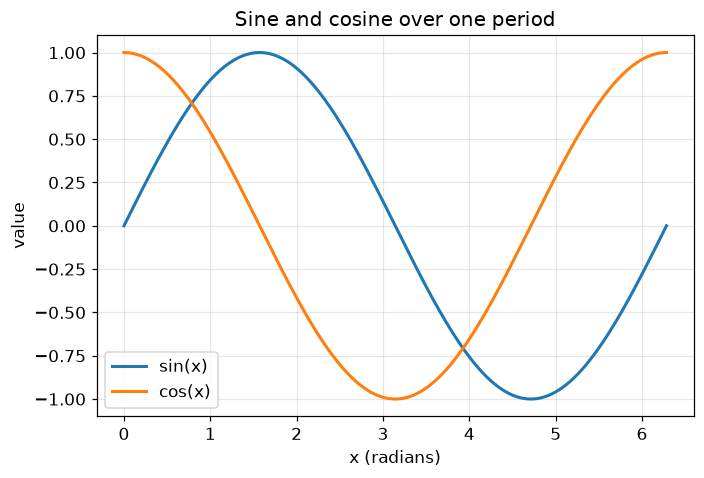

In [54]:
x = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_xlabel("x (radians)")
ax.set_ylabel("value")
ax.set_title("Sine and cosine over one period")
ax.legend()
plt.show()

### 5.3 Polynomials, as pairs of curves on shared axes

The same pattern applied to the polynomial examples from the drafts.
Plotting two functions of very different magnitude on one axes is itself
informative: the smaller one flattens out, which is a real limitation of a
shared linear scale rather than a mistake.

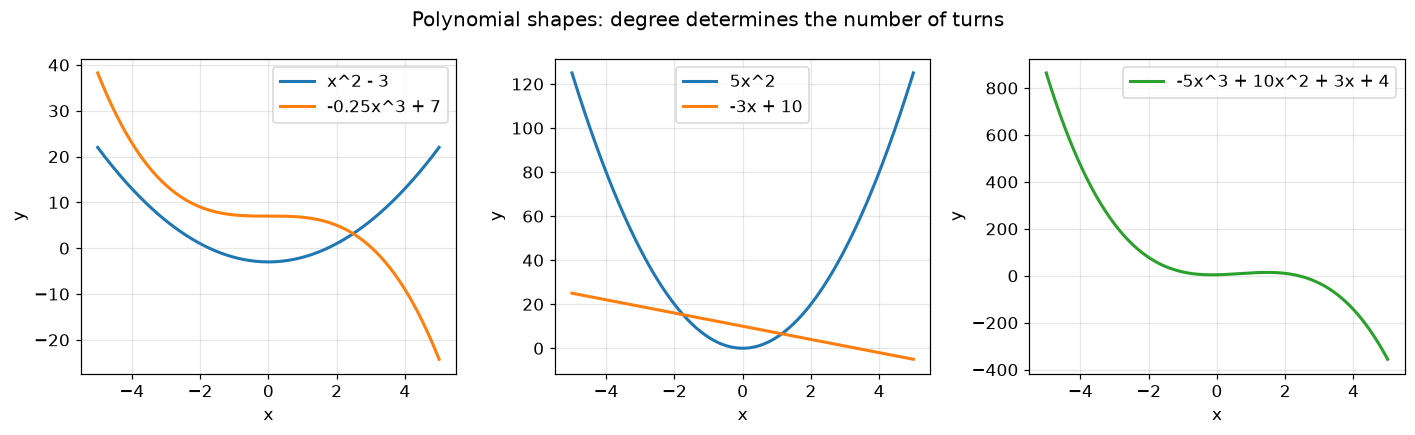

In [55]:
x = np.linspace(-5, 5, 300)

pairs = [
    (x ** 2 - 3, "x^2 - 3", -0.25 * x ** 3 + 7, "-0.25x^3 + 7"),
    (5 * x ** 2, "5x^2", -3 * x + 10, "-3x + 10"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (y_a, label_a, y_b, label_b) in zip(axes, pairs):
    ax.plot(x, y_a, label=label_a)
    ax.plot(x, y_b, label=label_b)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

axes[2].plot(x, -5 * x ** 3 + 10 * x ** 2 + 3 * x + 4, color="tab:green",
             label="-5x^3 + 10x^2 + 3x + 4")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].legend()

fig.suptitle("Polynomial shapes: degree determines the number of turns")
fig.tight_layout()
plt.show()

A polynomial of degree `d` has at most `d - 1` turning points. That fact
returns in Practice 3 §7, where fitting a high-degree polynomial to noisy
data produces exactly the wiggle you see on the right, and the wiggle is
the visual signature of overfitting.

`fig.tight_layout()` recomputes the spacing so that labels and titles do
not overlap. On a multi-panel figure it is effectively required.

### 5.4 Scatter plots

`ax.scatter` draws unconnected points. Use it when the x values have no
meaningful order — which for measured data is the usual case.

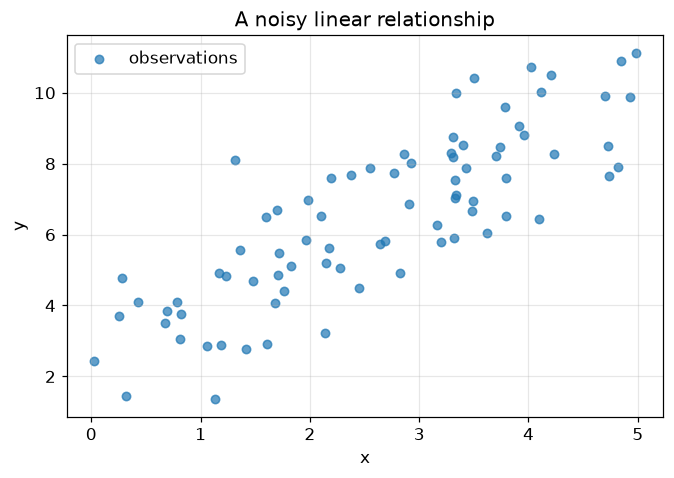

In [56]:
n_points = 80
x_obs = rng.uniform(0, 5, n_points)
y_obs = 2.0 * x_obs + 1.0 + rng.normal(0, 1.5, n_points)

fig, ax = plt.subplots()
ax.scatter(x_obs, y_obs, marker="o", color="tab:blue", s=30, alpha=0.7,
           label="observations")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("A noisy linear relationship")
ax.legend()
plt.show()

### 5.5 Overlaying the truth on the data

Because the data above was generated, the true relationship is known. Draw
it on top. This is the one situation in which you can see exactly how much
of the scatter is noise and how much is signal, and it is why synthetic
data is worth the trouble.

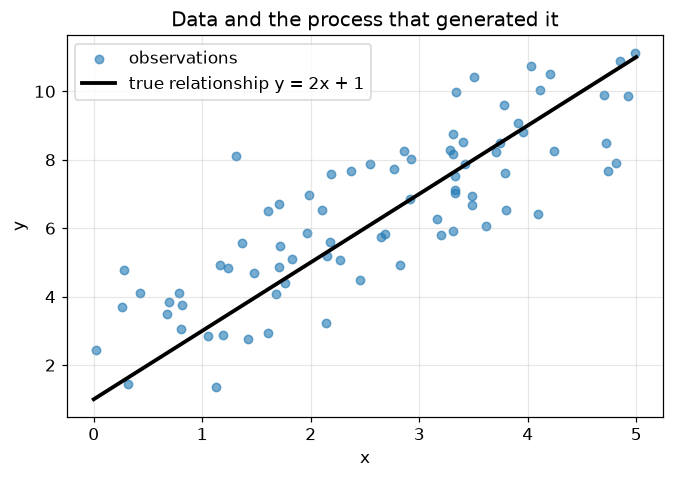

In [57]:
x_line = np.linspace(0, 5, 100)

fig, ax = plt.subplots()
ax.scatter(x_obs, y_obs, s=30, alpha=0.6, label="observations")
ax.plot(x_line, 2.0 * x_line + 1.0, color="black", linewidth=2.5,
        label="true relationship y = 2x + 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Data and the process that generated it")
ax.legend()
plt.show()

In Practice 3 §3 the black line is unknown and a model has to recover it from
the blue points alone. Keep this picture in mind: the model is not trying
to pass through the points, it is trying to find the line they were
scattered around.

### 5.6 The marker gallery

A reference figure, reproduced from the drafts. It is here so that you can
choose a marker by looking rather than by guessing at a letter.

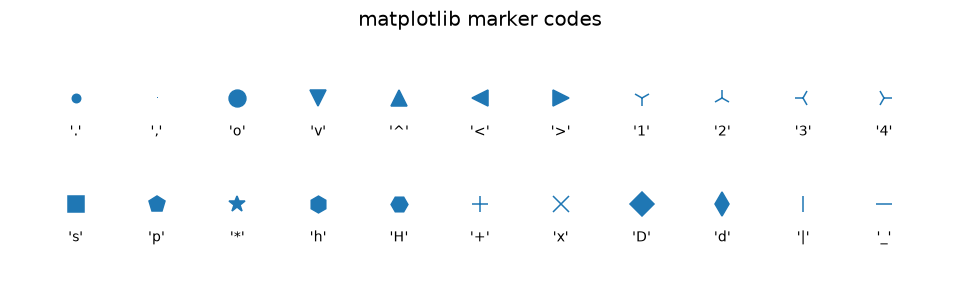

In [58]:
markers = ["." , "," , "o" , "v" , "^" , "<" , ">" , "1" , "2" , "3" , "4",
           "s" , "p" , "*" , "h" , "H" , "+" , "x" , "D" , "d" , "|" , "_"]

fig, ax = plt.subplots(figsize=(11, 3))
for i, marker in enumerate(markers):
    column, row = i % 11, i // 11
    ax.plot(column, -row, marker=marker, color="tab:blue", markersize=11)
    ax.text(column, -row - 0.35, repr(marker), ha="center", fontsize=9)

ax.set_xlim(-0.8, 10.8)
ax.set_ylim(-1.8, 0.6)
ax.axis("off")
ax.set_title("matplotlib marker codes")
plt.show()

`ax.axis("off")` removes the axes entirely. That is right for a gallery,
where the position of a marker carries no information, and wrong for
anything presenting data, which must carry a title and labelled axes with
units where units exist.

### 5.7 Figure size and resolution

`figsize` is given in **inches**, and `dpi` converts inches to pixels. A
figure of `figsize=(8, 4)` at `dpi=100` is 800 by 400 pixels. Changing
`figsize` changes the physical area; changing `dpi` changes how finely that
area is sampled. Text is specified in points, so enlarging `figsize` while
keeping the font size makes the text relatively smaller.

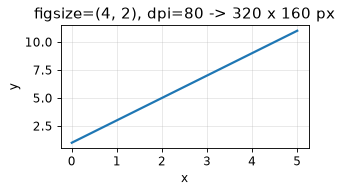

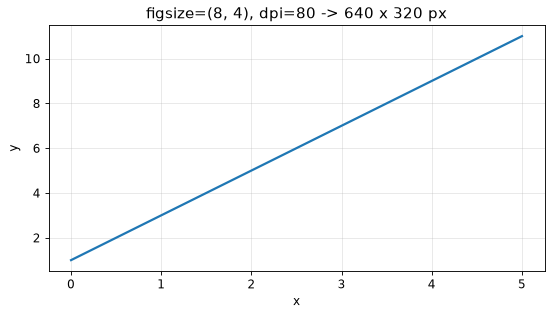

In [59]:
for size, dpi in [((4, 2), 80), ((8, 4), 80)]:
    fig, ax = plt.subplots(figsize=size, dpi=dpi)
    ax.plot(x_line, 2.0 * x_line + 1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"figsize={size}, dpi={dpi} -> {size[0]*dpi} x {size[1]*dpi} px")
    plt.show()

Both figures contain the same line with the same font size. The label text
occupies proportionally less of the larger figure. When a plot is destined
for a projector, set `figsize` for the aspect ratio you want and raise the
font size rather than shrinking the figure.

## 6. Two datasets for Lesson 3

Everything in this lesson now comes together into two small datasets. They
are built here, from the generator in §4, so that when Lesson 3 fits a model
to them you know precisely what the right answer is and can measure how
close the model got.

### 6.1 A synthetic regression dataset

One input, one continuous output, a straight-line relationship, and
additive noise:

$$y = a x + b + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

The parameters `a` and `b` are the quantities a regression will try to
recover.

In [60]:
regression_rng = np.random.default_rng(SEED)

true_a = 1.0
true_b = 3.0
noise_sigma = 1.0
n_regression = 200

x_regression = regression_rng.uniform(0, 5, n_regression)
noise = regression_rng.normal(0, noise_sigma, n_regression)
y_regression = true_a * x_regression + true_b + noise

print("x shape", x_regression.shape, " y shape", y_regression.shape)
print("true a =", true_a, " true b =", true_b, " noise sigma =", noise_sigma)
print("first five x:", x_regression[:5].round(3))
print("first five y:", y_regression[:5].round(3))

x shape (200,)  y shape (200,)
true a = 1.0  true b = 3.0  noise sigma = 1.0
first five x: [3.394 4.265 4.391 0.83  1.927]
first five y: [6.264 7.158 7.792 5.201 6.879]


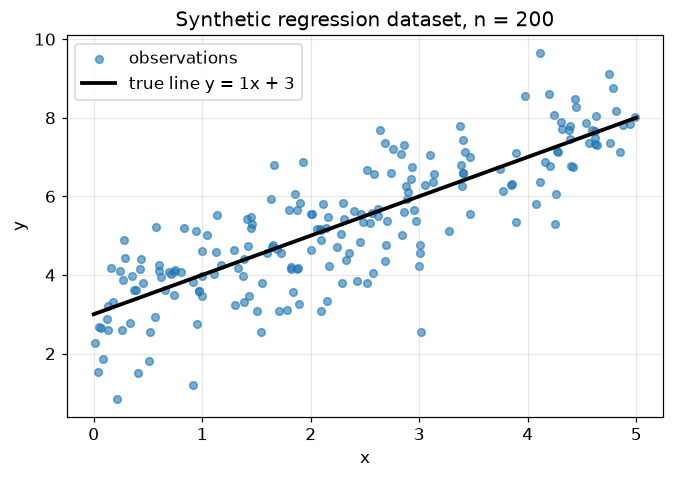

In [61]:
x_grid = np.linspace(0, 5, 100)

fig, ax = plt.subplots()
ax.scatter(x_regression, y_regression, s=25, alpha=0.6, label="observations")
ax.plot(x_grid, true_a * x_grid + true_b, color="black", linewidth=2.5,
        label=f"true line y = {true_a:.0f}x + {true_b:.0f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Synthetic regression dataset, n = {n_regression}")
ax.legend()
plt.show()

Practice 3 §3 fits a linear regression to `x_regression` and `y_regression`
and compares the recovered coefficient and intercept against `true_a` and
`true_b`. Note that the model will receive `x_regression.reshape(-1, 1)`,
for the reason given in §3.5.

Two properties of this dataset matter later. The noise is **additive** and
has **constant variance** — the scatter is as wide at `x = 5` as at
`x = 0`. Both are assumptions of ordinary least squares, and both are
often false for real measurements.

### 6.2 A synthetic classification dataset

Two classes, each a Gaussian cloud in two dimensions, with different means
and different spreads. The covariance matrices come straight from §4.9:
one is the identity, the other is twice the identity, so the second class
is the wider of the two.

In [62]:
classification_rng = np.random.default_rng(SEED + 1)

mean_class_0 = np.array([1.0, 2.0])
cov_class_0 = np.eye(2)             # identity: circular, unit spread

mean_class_1 = np.array([4.0, 5.0])
cov_class_1 = 2.0 * np.eye(2)       # circular, wider by sqrt(2)

n_per_class = 150

points_class_0 = classification_rng.multivariate_normal(mean_class_0, cov_class_0, n_per_class)
points_class_1 = classification_rng.multivariate_normal(mean_class_1, cov_class_1, n_per_class)

X_classification = np.concatenate([points_class_0, points_class_1], axis=0)
y_classification = np.concatenate([np.zeros(n_per_class, dtype=int),
                                   np.ones(n_per_class, dtype=int)])

print("X shape", X_classification.shape, " y shape", y_classification.shape)
print("class counts:", np.bincount(y_classification))
print("\ncovariance of class 0:\n", cov_class_0)
print("covariance of class 1:\n", cov_class_1)

X shape (300, 2)  y shape (300,)
class counts: [150 150]

covariance of class 0:
 [[1. 0.]
 [0. 1.]]
covariance of class 1:
 [[2. 0.]
 [0. 2.]]


`X` has one row per sample and one column per feature, which is the layout
every scikit-learn estimator expects. `y` is a 1-D array of labels of the
same length. That pairing — a 2-D `X` and a 1-D `y` with matching first
dimension — is the interface for the whole of Lesson 3.

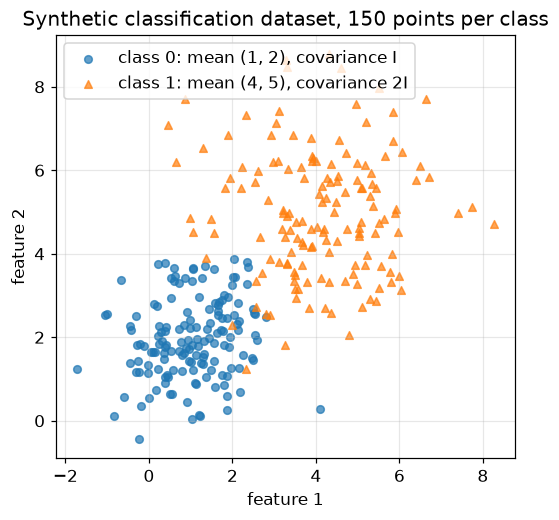

In [63]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(points_class_0[:, 0], points_class_0[:, 1], s=25, alpha=0.7,
           label="class 0: mean (1, 2), covariance I")
ax.scatter(points_class_1[:, 0], points_class_1[:, 1], s=25, alpha=0.7,
           marker="^", label="class 1: mean (4, 5), covariance 2I")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title(f"Synthetic classification dataset, {n_per_class} points per class")
ax.set_aspect("equal")
ax.legend()
plt.show()

The two clouds overlap in the middle. That overlap is deliberate and it
sets a ceiling on accuracy: no classifier, however good, can separate
points that genuinely came from both distributions. Practice 3 §5 makes that
ceiling explicit, and it is the reason a reported accuracy below 100 % is
not by itself evidence of a bad model.

## 7. Discussion

Eight questions for the room. Each answer is given, so work through the
question before reading on.

**7.1 — You slice an array, pass the slice to a function, and the original
array changes. What happened, and what are the two ways to prevent it?**

The slice was a view sharing the parent's buffer (§3.6), and the function
mutated it in place. Prevent it either by passing `arr[a:b].copy()`, or by
writing the function so that it returns a new array instead of modifying
its argument. The second is the better habit: a function that mutates its
input is hard to reason about regardless of NumPy.

**7.2 — `arr.sum(axis=0)` on a `(100, 5)` array: what shape comes back, and
what does each number mean?**

Shape `(5,)`. `axis=0` collapses the 100 rows, so you get one total per
column — that is, one number per feature, summed over all samples (§3.8).

**7.3 — You increase a histogram's `bins` from 10 to 200 on the same
sample. What changes, and which picture is correct?**

Both are correct renderings of the same data; neither is the truth. Few
bins smooth away real structure, many bins expose sampling noise as
spurious peaks. The bin count is a choice made by the analyst, and Practice 2
§10.2 shows a case where the default choice invents a bimodality that is
not in the data.

**7.4 — Your 3σ filter flags 27 points in a sample of 10 000 normal draws.
Should you remove them?**

No. That is almost exactly the expected count (0.27 %, §4.7). The filter
found the tail of the distribution it was told to expect. Removal is
justified by knowledge of the measurement process — a sensor that reports
-999 for a failed reading — not by the value being far from the mean.

**7.5 — The off-diagonal entry of a 2×2 covariance matrix is changed from 0
to -6 while the diagonal stays at 9. What happens to the cloud?**

It tilts down to the right instead of staying axis-aligned: the
correlation becomes -6/9 ≈ -0.67, so large `x` goes with small `y` (§4.9).
The marginal spread along each individual axis is unchanged, which is why
looking at one variable at a time cannot detect correlation.

**7.6 — Why does `0.1 + 0.2 == 0.3` return `False`, and why does this
matter for an assertion in your homework?**

Neither 0.1 nor 0.2 is exactly representable in binary floating point, so
their sum differs from the stored value of 0.3 by about 5.6e-17 (§3.11).
Any test comparing computed floats must use a tolerance — `np.isclose` —
or it will fail on arithmetic that is entirely correct.

**7.7 — Two colleagues run the same notebook and get different numbers.
Name three possible causes.**

No seed, or a seed set in a cell that was not re-run; cells executed out of
order, so the shared generator was at a different point in its stream
(§4.1); different library versions changing a default. The first two are
why this notebook creates one `rng` in §1 and why restart-and-run-all is
the only trustworthy check; the third is why §1 prints the versions.

**7.8 — Why does this course generate its synthetic data explicitly instead
of calling a library function that returns two ready-made blobs?**

Because the parameters of the generator are the answer key. You chose the
means, the covariances and the noise level, so when a model reports a
coefficient you can say how close it is, and when a clustering method
fails you can say which of its assumptions your data violated. A function
that hands back an anonymous pair of crescents teaches nothing about why
they are hard to separate.

## 8. Summary and what comes next

This lesson covered representation and computation:

- Python's containers, and why they are the wrong tool for numerical work
  (§2).
- The `ndarray`: `dtype`, `shape`, the contiguous typed buffer and the
  measured speedup that follows from it; views against copies;
  broadcasting; axis semantics; masking; `NaN`; floating point (§3).
- Seeded generation with `default_rng`, the distributions this course uses,
  parameter recovery, the 3σ rule, and the covariance matrix read as the
  shape and tilt of a cloud (§4).
- Figures built from `Figure` and `Axes`, labelled so that they can be read
  without a caption (§5).
- Two synthetic datasets, with known parameters, for Lesson 3 (§6).

**Lesson 2** takes arrays and attaches an index and column names to them,
which turns them into a table that can have missing values, mixed types and
categories. Everything above still applies underneath: a pandas column is an
`ndarray` with a label, and `.values` hands the array back to you.

**Lesson 3** fits models to the datasets from §6 and to the cleaned table
Lesson 2 produces.

### Further reading

- NumPy user guide and reference — <https://numpy.org>
- Matplotlib documentation and gallery — <https://matplotlib.org>
- NumPy `reshape` reference —
  <https://numpy.org/doc/stable/reference/generated/numpy.reshape.html>
- Random sampling with `Generator` —
  <https://numpy.org/doc/stable/reference/random/generator.html>
- Broadcasting rules —
  <https://numpy.org/doc/stable/user/basics.broadcasting.html>